In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
import joblib

print("-> Loading and preparing: Bank Churn Dataset")

# 1. Load the dataset
df = pd.read_csv('./data/Customer-Churn-Records.csv')

# 2. Drop identifiers and 'Complain' (to prevent the data leak!)
df = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Complain'], axis=1)

target = 'Exited'
y = df[target]
X = df.drop(target, axis=1)


numeric = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Point Earned']
categorical = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Satisfaction Score', 'Card Type']

# 4. Preprocessing Pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical)
])

# 5. Split and Transform
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("✅ Cell 1 Complete: Single Bank Churn dataset preprocessed and ready!")

-> Loading and preparing: Bank Churn Dataset
✅ Cell 1 Complete: Single Bank Churn dataset preprocessed and ready!


In [3]:
def build_ffnn(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

print("✅ Cell 2 Complete: Neural Network architecture successfully loaded into memory!")

✅ Cell 2 Complete: Neural Network architecture successfully loaded into memory!



🚀 TRAINING: CUSTOMER IQ NEURAL NETWORK


c:\Users\HP\Documents\dissertation-project\apps\ml-engine\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6740 - auc: 0.6336 - loss: 0.6144 - val_accuracy: 0.8300 - val_auc: 0.7542 - val_loss: 0.4562
Epoch 2/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7897 - auc: 0.7417 - loss: 0.4591 - val_accuracy: 0.8400 - val_auc: 0.8084 - val_loss: 0.3823
Epoch 3/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8197 - auc: 0.7868 - loss: 0.4148 - val_accuracy: 0.8562 - val_auc: 0.8292 - val_loss: 0.3570
Epoch 4/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8275 - auc: 0.8061 - loss: 0.4000 - val_accuracy: 0.8675 - val_auc: 0.8407 - val_loss: 0.3490
Epoch 5/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8347 - auc: 0.8226 - loss: 0.3863 - val_accuracy: 0.8675 - val_auc: 0.8427 - val_loss: 0.3427
Epoch 6/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8358 - auc: 0.8239 - loss: 0.3847 - val_accuracy: 0.8712 - val_auc: 0.8416 - val_loss: 0.3427
Epoch 7/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 

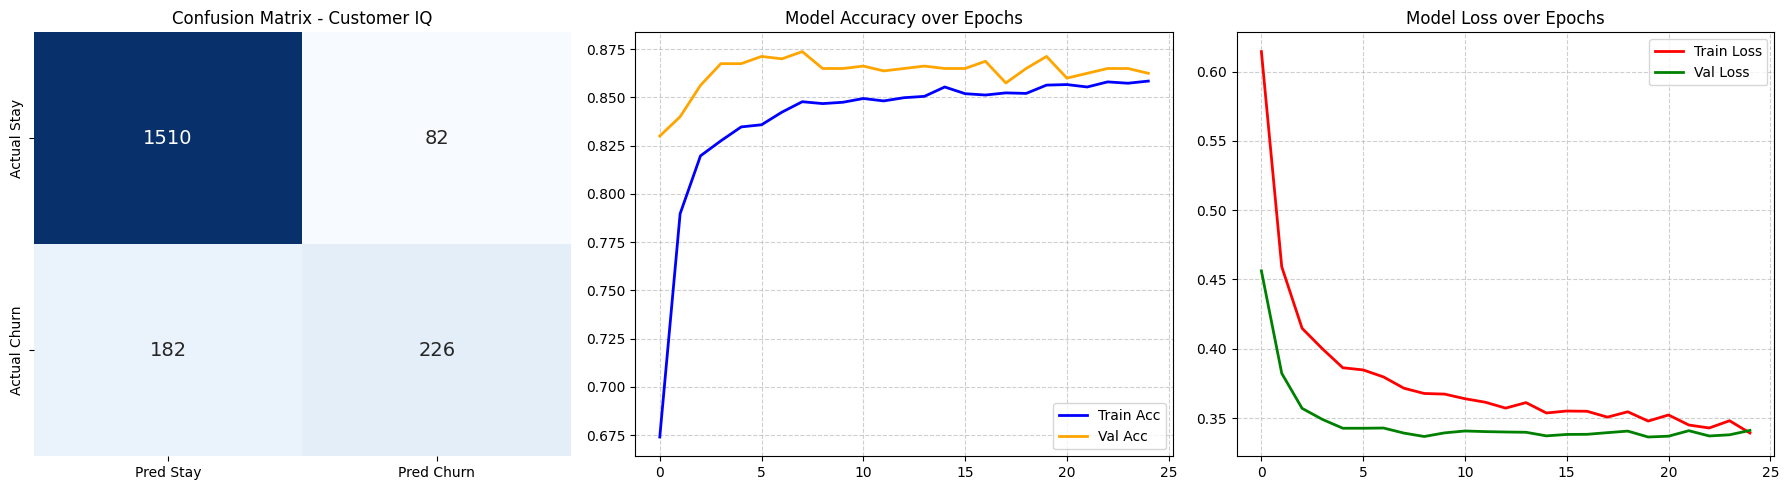


✅ Model and Preprocessor saved successfully for backend deployment!


In [4]:
print(f"\n{'='*40}")
print(f"🚀 TRAINING: CUSTOMER IQ NEURAL NETWORK")
print(f"{'='*40}")

# 1. Build Model based on our specific feature count
model = build_ffnn(X_train_proc.shape[1])

# 2. Train Model
history = model.fit(
    X_train_proc, y_train,
    epochs=25, # Slightly bumped epochs since we are focusing on one dataset
    batch_size=32,
    validation_split=0.1,
    verbose=1 # Let's see the training process now!
)

# 3. Evaluate Metrics
metrics = model.evaluate(X_test_proc, y_test, verbose=0)
acc, auc = metrics[1], metrics[2]

y_pred_prob = model.predict(X_test_proc, verbose=0)
y_pred = (y_pred_prob > 0.50).astype(int).flatten()

print(f"\n🎯 FINAL RESULTS: Accuracy: {acc:.4f} | AUC: {auc:.4f}")
print("\n--- Classification Report ---")
report = classification_report(y_test, y_pred, target_names=['Stay (0)', 'Churn (1)'], output_dict=True)
print(classification_report(y_test, y_pred, target_names=['Stay (0)', 'Churn (1)']))

# 4. Generate Visualizations (Confusion Matrix, Accuracy, Loss)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Pred Stay', 'Pred Churn'],
            yticklabels=['Actual Stay', 'Actual Churn'],
            annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix - Customer IQ')

# Accuracy Graph
axes[1].plot(history.history['accuracy'], label='Train Acc', color='blue', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='orange', linewidth=2)
axes[1].set_title('Model Accuracy over Epochs')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

# Loss Graph
axes[2].plot(history.history['loss'], label='Train Loss', color='red', linewidth=2)
axes[2].plot(history.history['val_loss'], label='Val Loss', color='green', linewidth=2)
axes[2].set_title('Model Loss over Epochs')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('bank_churn_training_metrics.png', dpi=300)
plt.show() 

# 5. Save the models for the Customer IQ Backend!
model.save('bank_churn_model.keras')
joblib.dump(preprocessor, 'bank_churn_preprocessor.pkl')
print("\n✅ Model and Preprocessor saved successfully for backend deployment!")

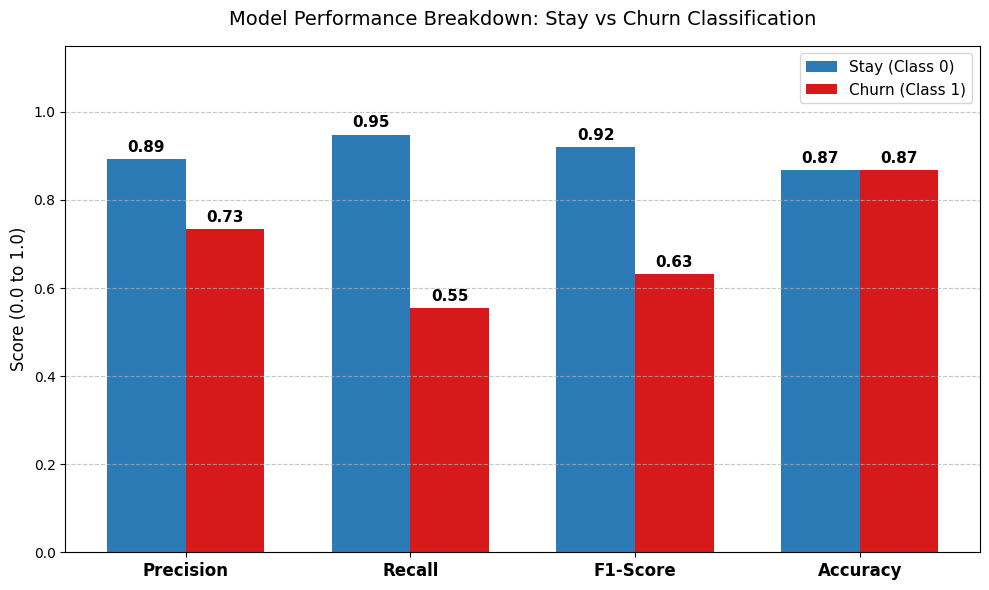

✅ Chapter 4 Performance Graph generated and saved as dissertation_class_performance.png!


In [5]:
# Create a dedicated Chapter 4 Bar Chart: Precision vs Recall vs F1 vs Accuracy
metrics_to_plot = {
    'Precision': [report['Stay (0)']['precision'], report['Churn (1)']['precision']],
    'Recall': [report['Stay (0)']['recall'], report['Churn (1)']['recall']],
    'F1-Score': [report['Stay (0)']['f1-score'], report['Churn (1)']['f1-score']],
    'Accuracy': [report['accuracy'], report['accuracy']]  # Global accuracy added to both bars
}

x = np.arange(len(metrics_to_plot.keys()))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6)) # Made slightly wider (10) to fit the 4th metric
rects1 = ax.bar(x - width/2, [m[0] for m in metrics_to_plot.values()], width, label='Stay (Class 0)', color='#2c7bb6')
rects2 = ax.bar(x + width/2, [m[1] for m in metrics_to_plot.values()], width, label='Churn (Class 1)', color='#d7191c')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12)
ax.set_title('Model Performance Breakdown: Stay vs Churn Classification', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot.keys(), fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=11)

# Attach labels
ax.bar_label(rects1, padding=3, fmt='%.2f', fontsize=11, fontweight='bold')
ax.bar_label(rects2, padding=3, fmt='%.2f', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('dissertation_class_performance.png', dpi=300)
plt.show()

print("✅ Chapter 4 Performance Graph generated and saved as dissertation_class_performance.png!")

🚀 RUNNING FINAL EXAM: EVALUATING ON TEST SET...

✅ FINAL TEST RESULTS:
Test Loss:     0.3343
Test Accuracy: 0.8660 (86.60%)
Test AUC:      0.8661

--- Test Set Classification Report ---
              precision    recall  f1-score   support

    Stay (0)       0.89      0.95      0.92      1592
   Churn (1)       0.73      0.55      0.63       408

    accuracy                           0.87      2000
   macro avg       0.81      0.75      0.77      2000
weighted avg       0.86      0.87      0.86      2000


📊 Generating Test Set Confusion Matrix...


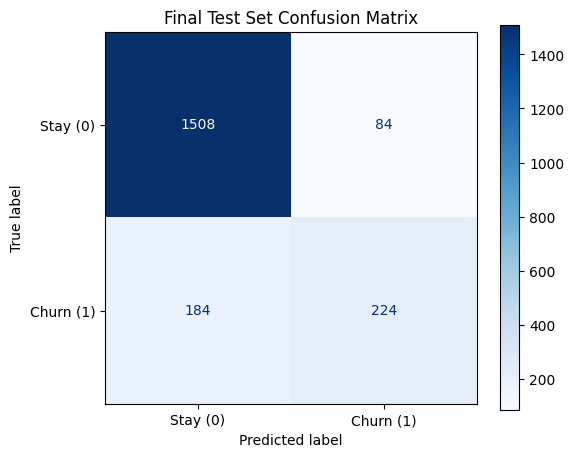

In [7]:
# ====================================================
# FINAL MODEL EVALUATION ON UNSEEN TEST DATA
# ====================================================
print("🚀 RUNNING FINAL EXAM: EVALUATING ON TEST SET...")

# 1. Evaluate the model on the locked-away test data
test_metrics = model.evaluate(X_test_proc, y_test, verbose=0)
test_loss, test_acc, test_auc = test_metrics[0], test_metrics[1], test_metrics[2]

print(f"\n✅ FINAL TEST RESULTS:")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({(test_acc*100):.2f}%)")
print(f"Test AUC:      {test_auc:.4f}")

# 2. Get detailed predictions for the Classification Report
y_test_pred_prob = model.predict(X_test_proc, verbose=0)
y_test_pred = (y_test_pred_prob > 0.50).astype(int).flatten()

print("\n--- Test Set Classification Report ---")
print(classification_report(y_test, y_test_pred, target_names=['Stay (0)', 'Churn (1)']))

# Optional: Generate a Confusion Matrix just for the Test Set
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\n📊 Generating Test Set Confusion Matrix...")
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_test_pred, 
    display_labels=['Stay (0)', 'Churn (1)'], 
    cmap='Blues', 
    ax=ax
)
plt.title('Final Test Set Confusion Matrix')
plt.show()

In [9]:
import pandas as pd

print(f"{'='*40}")
print("🔮 LIVE INFERENCE: SINGLE CUSTOMER TEST")
print(f"{'='*40}")

# 1. Create a fake customer profile
# (You can change these values live in front of your supervisor to show how it works!)
new_customer_data = {
    'CreditScore': [600],
    'Geography': ['France'],
    'Gender': ['Female'],
    'Age': [42],
    'Tenure': [3],
    'Balance': [1000000.50],
    'NumOfProducts': [1],
    'HasCrCard': [1],        # 1 for Yes, 0 for No
    'IsActiveMember': [0],   # 1 for Yes, 0 for No
    'EstimatedSalary': [85000.00],
    'Satisfaction Score': [2],
    'Card Type': ['DIAMOND'],
    'Point Earned': [450]
}

# 2. Convert to a Pandas DataFrame (which the preprocessor expects)
new_customer_df = pd.DataFrame(new_customer_data)

# 3. Apply the exact same preprocessing (Scaling & One-Hot Encoding)
# Note: We use .transform() NOT .fit_transform() because we use the rules learned from training
new_customer_proc = preprocessor.transform(new_customer_df)

# 4. Make the Prediction
churn_probability = model.predict(new_customer_proc, verbose=0)[0][0]

# 5. Display the Results
prediction_label = "CHURN 🔴" if churn_probability > 0.50 else "STAY 🟢"

print("\n🧑‍💼 CUSTOMER PROFILE:")
for key, value in new_customer_data.items():
    print(f"   - {key}: {value[0]}")

print("\n📊 MODEL PREDICTION:")
print(f"   - Churn Probability: {churn_probability * 100:.2f}%")
print(f"   - Final Verdict:     Customer will likely {prediction_label}")


🔮 LIVE INFERENCE: SINGLE CUSTOMER TEST

🧑‍💼 CUSTOMER PROFILE:
   - CreditScore: 600
   - Geography: France
   - Gender: Female
   - Age: 42
   - Tenure: 3
   - Balance: 1000000.5
   - NumOfProducts: 1
   - HasCrCard: 1
   - IsActiveMember: 0
   - EstimatedSalary: 85000.0
   - Satisfaction Score: 2
   - Card Type: DIAMOND
   - Point Earned: 450

📊 MODEL PREDICTION:
   - Churn Probability: 94.23%
   - Final Verdict:     Customer will likely CHURN 🔴
